In [1]:
import json
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import sys
from collections import defaultdict
sys.path.append('../..')
from style_setup import set_thesis_style
set_thesis_style()


# IMPORTANT: Need to include indices to make nice analysis graph

# Extracting, saving, and analyzing scores

## Helper function

In [8]:
def process_and_filter_judgements(file_paths):
    """
    Processes and filters a set of JSONL judgement files to ensure comparability.

    It first parses all files, marking any lines that fail parsing as exceptions.
    It then identifies any index where at least one model produced an exception
    and removes the data for that index from ALL models.

    Args:
        file_paths (dict): A dictionary mapping a condition name (e.g., 'single')
                           to the absolute path of the JSONL file.

    Returns:
        tuple: A tuple containing three dictionaries: (scores_dict, reasons_dict, indices_dict)
               where the data has been filtered for comparability.
    """
    # --- 1. Initial Pass: Parse all files, marking exceptions with None ---
    raw_results = defaultdict(list)
    
    for model, path in file_paths.items():
        try:
            with open(path, 'r') as f:
                for line in f:
                    data = json.loads(line)
                    judgement = data.get("judgement", "").strip()
                    if not judgement:
                        raw_results[model].append(None) # Treat empty judgements as exceptions
                        continue

                    lines = judgement.splitlines()
                    first_line = lines[0].strip()
                    score_found = None
                    
                    cleaned_first_line = first_line.replace('*', '')
                    if cleaned_first_line.lower().startswith('score'):
                        score_match = re.search(r'\d+', cleaned_first_line)
                        if score_match: score_found = int(score_match.group(0))
                    elif first_line and first_line[0].isdigit():
                        score_match = re.search(r'^\d+', first_line)
                        if score_match: score_found = int(score_match.group(0))

                    if score_found is not None:
                        reason = "\n".join(lines[2:]).strip() if len(lines) >= 3 else ""
                        raw_results[model].append((score_found, reason))
                    else:
                        raw_results[model].append(None) # Mark parsing failure

        except FileNotFoundError:
            print(f"Warning: File not found at {path}. All data for model '{model}' will be empty.")
        except json.JSONDecodeError:
            print(f"Warning: Could not decode JSON in file {path}. Skipping file.")

    # --- 2. Identify Indices to Remove ---
    indices_to_remove = set()
    model_keys = list(raw_results.keys())
    
    # Ensure all lists have the same length for zipping, pad if a file was missing/empty
    if raw_results:
        max_len = max(len(v) for v in raw_results.values())
        for model in model_keys:
            raw_results[model].extend([None] * (max_len - len(raw_results[model])))
    
    # Zip the results together to compare them index-by-index
    zipped_results = zip(*(raw_results[model] for model in model_keys))
    
    for i, result_tuple in enumerate(zipped_results):
        # If any item at this index is None (an exception), mark index for removal
        if any(item is None for item in result_tuple):
            indices_to_remove.add(i)

    # --- 3. Final Pass: Build clean dictionaries ---
    final_scores = defaultdict(list)
    final_reasons = defaultdict(list)
    final_indices = defaultdict(list)

    for model in model_keys:
        for i, result in enumerate(raw_results[model]):
            # Only include data from indices that are NOT marked for removal
            if i not in indices_to_remove:
                score, reason = result
                final_scores[model].append(score)
                final_reasons[model].append(reason)
                final_indices[model].append(i)
                
    return final_scores, final_reasons, final_indices

## Llama small

In [9]:
# --- Define File Paths (using absolute paths as requested) ---
refusalbench_only_paths_small_quality = {
    "single": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/small/rb/rb_8b_single_judged.jsonl",
    "multi": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/small/rb/rb_8b_multi_judged.jsonl",
    "human": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/small/rb/rb_8b_human_judged.jsonl",
    "vanilla": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/small/rb/rb_8b_vanilla_judged.jsonl"
}

refusalbench_jailbreak_paths_small_quality = {
    "single": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/small/rb_jb/rb_jb_8b_single_judged.jsonl",
    "multi": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/small/rb_jb/rb_jb_8b_multi_judged.jsonl",
    "human": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/small/rb_jb/rb_jb_8b_human_judged.jsonl",
    "vanilla": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/small/rb_jb/rb_jb_8b_vanilla_judged.jsonl"
}


# --- Process Both Sets of Files ---
print("Processing RefusalBench Only files...")
(rb_only_scores, rb_only_reasons, rb_only_indices) = process_and_filter_judgements(refusalbench_only_paths_small_quality)

print("\nProcessing RefusalBench + Jailbreak files...")
(rb_jb_scores, rb_jb_reasons, rb_jb_indices) = process_and_filter_judgements(refusalbench_jailbreak_paths_small_quality)

# --- Print Summary of Filtered Results ---
print("\n--- Summary of Comparable Results ---")
# Use the keys from one of the path dicts to ensure we check all expected models
for model_key in refusalbench_only_paths_small_quality.keys():
    print(f"\nModel: '{model_key}'")
    print(f"  - RB Only:     {len(rb_only_scores.get(model_key, []))} scores/reasons.")
    print(f"  - RB+Jailbreak:  {len(rb_jb_scores.get(model_key, []))} scores/reasons.")


Processing RefusalBench Only files...

Processing RefusalBench + Jailbreak files...

--- Summary of Comparable Results ---

Model: 'single'
  - RB Only:     885 scores/reasons.
  - RB+Jailbreak:  925 scores/reasons.

Model: 'multi'
  - RB Only:     885 scores/reasons.
  - RB+Jailbreak:  925 scores/reasons.

Model: 'human'
  - RB Only:     885 scores/reasons.
  - RB+Jailbreak:  925 scores/reasons.

Model: 'vanilla'
  - RB Only:     885 scores/reasons.
  - RB+Jailbreak:  925 scores/reasons.


In [13]:
print("Mean quality score for refusalbench only, single source: ", sum(rb_only_scores["single"])/len(rb_only_scores["single"]))
print("Mean quality score for refusalbench only, multi source: ", sum(rb_only_scores["multi"])/len(rb_only_scores["multi"]))
print("Mean quality score for refusalbench only, human source: ", sum(rb_only_scores["human"])/len(rb_only_scores["human"]))
print("Mean quality score for refusalbench only, vanilla: ", sum(rb_only_scores["vanilla"])/len(rb_only_scores["vanilla"]))

print("Mean harmfulness score for refusalbench + jailbreak, single source: ", sum(rb_jb_scores["single"])/len(rb_jb_scores["single"]))
print("Mean harmfulness score for refusalbench + jailbreak, multi source: ", sum(rb_jb_scores["multi"])/len(rb_jb_scores["multi"]))
print("Mean harmfulness score for refusalbench + jailbreak, human source: ", sum(rb_jb_scores["human"])/len(rb_jb_scores["human"]))
print("Mean harmfulness score for refusalbench + jailbreak, vanilla: ", sum(rb_jb_scores["vanilla"])/len(rb_jb_scores["vanilla"]))


quality_scores_dict_small = {
    "refusalbench_only": {
        "scores": rb_only_scores,
        "reasons": rb_only_reasons,
        "indices": rb_only_indices
    },
    "refusalbench_jailbreak": {
        "scores": rb_jb_scores,
        "reasons": rb_jb_reasons,
        "indices": rb_jb_indices
    }
}


Mean quality score for refusalbench only, single source:  4.595480225988701
Mean quality score for refusalbench only, multi source:  4.8
Mean quality score for refusalbench only, human source:  2.663276836158192
Mean quality score for refusalbench only, vanilla:  4.622598870056497
Mean harmfulness score for refusalbench + jailbreak, single source:  3.84972972972973
Mean harmfulness score for refusalbench + jailbreak, multi source:  3.558918918918919
Mean harmfulness score for refusalbench + jailbreak, human source:  2.455135135135135
Mean harmfulness score for refusalbench + jailbreak, vanilla:  3.5491891891891894


In [14]:
import json

output_path = "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/small/quality_scores_dict_small.json"
# Convert any non-serializable values (e.g., numpy types) to native Python types
def convert(o):
    if isinstance(o, (float, int, str, bool)):
        return o
    if hasattr(o, "tolist"):
        return o.tolist()
    if isinstance(o, dict):
        return {k: convert(v) for k, v in o.items()}
    if isinstance(o, list):
        return [convert(i) for i in o]
    return str(o)

with open(output_path, "w") as f:
    json.dump(convert(quality_scores_dict_small), f, indent=2)
print(f"Saved quality_scores_dict_small to {output_path}")


Saved quality_scores_dict_small to /Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/small/quality_scores_dict_small.json


## Llama medium

In [15]:
# --- Define File Paths (using absolute paths as requested) ---
refusalbench_only_paths_small_quality = {
    "single small": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/medium/rb/rb_70b_single_judged_small.jsonl",
    "single medium": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/medium/rb/rb_70b_single_judged_medium.jsonl",
    "single large": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/medium/rb/rb_70b_single_judged_large.jsonl",
    "multi small": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/medium/rb/rb_70b_multi_judged_small.jsonl",
    "multi medium": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/medium/rb/rb_70b_multi_judged_medium.jsonl",
    "multi large": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/medium/rb/rb_70b_multi_judged_large.jsonl",
    "human": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/medium/rb/rb_70b_human_judged.jsonl",
    "vanilla": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/medium/rb/rb_70b_vanilla_judged.jsonl"
}

refusalbench_jailbreak_paths_small_quality = {
    "single small": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/medium/rb_jb/rb_jb_70b_single_judged_small.jsonl",
    "single medium": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/medium/rb_jb/rb_jb_70b_single_judged_medium.jsonl",
    "single large": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/medium/rb_jb/rb_jb_70b_single_judged_large.jsonl",
    "multi small": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/medium/rb_jb/rb_jb_70b_multi_judged_small.jsonl",
    "multi medium": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/medium/rb_jb/rb_jb_70b_multi_judged_medium.jsonl",
    "multi large": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/medium/rb_jb/rb_jb_70b_multi_judged_large.jsonl",
    "human": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/medium/rb_jb/rb_jb_70b_human_judged.jsonl",
    "vanilla": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/medium/rb_jb/rb_jb_70b_vanilla_judged.jsonl"
}


# --- Process Both Sets of Files ---
print("Processing RefusalBench Only files...")
(rb_only_scores, rb_only_reasons, rb_only_indices) = process_and_filter_judgements(refusalbench_only_paths_small_quality)

print("\nProcessing RefusalBench + Jailbreak files...")
(rb_jb_scores, rb_jb_reasons, rb_jb_indices) = process_and_filter_judgements(refusalbench_jailbreak_paths_small_quality)


# --- Print Summary of Filtered Results ---
print("\n--- Summary of Comparable Results ---")
# Use the keys from one of the path dicts to ensure we check all expected models
for model_key in refusalbench_only_paths_small_quality.keys():
    print(f"\nModel: '{model_key}'")
    print(f"  - RB Only:     {len(rb_only_scores.get(model_key, []))} scores/reasons.")
    print(f"  - RB+Jailbreak:  {len(rb_jb_scores.get(model_key, []))} scores/reasons.")


Processing RefusalBench Only files...

Processing RefusalBench + Jailbreak files...

--- Summary of Comparable Results ---

Model: 'single small'
  - RB Only:     886 scores/reasons.
  - RB+Jailbreak:  895 scores/reasons.

Model: 'single medium'
  - RB Only:     886 scores/reasons.
  - RB+Jailbreak:  895 scores/reasons.

Model: 'single large'
  - RB Only:     886 scores/reasons.
  - RB+Jailbreak:  895 scores/reasons.

Model: 'multi small'
  - RB Only:     886 scores/reasons.
  - RB+Jailbreak:  895 scores/reasons.

Model: 'multi medium'
  - RB Only:     886 scores/reasons.
  - RB+Jailbreak:  895 scores/reasons.

Model: 'multi large'
  - RB Only:     886 scores/reasons.
  - RB+Jailbreak:  895 scores/reasons.

Model: 'human'
  - RB Only:     886 scores/reasons.
  - RB+Jailbreak:  895 scores/reasons.

Model: 'vanilla'
  - RB Only:     886 scores/reasons.
  - RB+Jailbreak:  895 scores/reasons.


In [16]:
print("Mean quality score for refusalbench only, single source small: ", sum(rb_only_scores["single small"])/len(rb_only_scores["single small"]))
print("Mean quality score for refusalbench only, single source medium: ", sum(rb_only_scores["single medium"])/len(rb_only_scores["single medium"]))
print("Mean quality score for refusalbench only, single source large: ", sum(rb_only_scores["single large"])/len(rb_only_scores["single large"]))

print("Mean quality score for refusalbench only, multi source small: ", sum(rb_only_scores["multi small"])/len(rb_only_scores["multi small"]))
print("Mean quality score for refusalbench only, multi source medium: ", sum(rb_only_scores["multi medium"])/len(rb_only_scores["multi medium"]))
print("Mean quality score for refusalbench only, multi source large: ", sum(rb_only_scores["multi large"])/len(rb_only_scores["multi large"]))

print("Mean quality score for refusalbench only, human source: ", sum(rb_only_scores["human"])/len(rb_only_scores["human"]))
print("Mean quality score for refusalbench only, vanilla: ", sum(rb_only_scores["vanilla"])/len(rb_only_scores["vanilla"]))

print("Mean harmfulness score for refusalbench + jailbreak, single source small: ", sum(rb_jb_scores["single small"])/len(rb_jb_scores["single small"]))
print("Mean harmfulness score for refusalbench + jailbreak, single source medium: ", sum(rb_jb_scores["single medium"])/len(rb_jb_scores["single medium"]))
print("Mean harmfulness score for refusalbench + jailbreak, single source large: ", sum(rb_jb_scores["single large"])/len(rb_jb_scores["single large"]))

print("Mean harmfulness score for refusalbench + jailbreak, multi source small: ", sum(rb_jb_scores["multi small"])/len(rb_jb_scores["multi small"]))
print("Mean harmfulness score for refusalbench + jailbreak, multi source medium: ", sum(rb_jb_scores["multi medium"])/len(rb_jb_scores["multi medium"]))
print("Mean harmfulness score for refusalbench + jailbreak, multi source large: ", sum(rb_jb_scores["multi large"])/len(rb_jb_scores["multi large"]))

print("Mean harmfulness score for refusalbench + jailbreak, human source: ", sum(rb_jb_scores["human"])/len(rb_jb_scores["human"]))
print("Mean harmfulness score for refusalbench + jailbreak, vanilla: ", sum(rb_jb_scores["vanilla"])/len(rb_jb_scores["vanilla"]))


quality_scores_dict_medium = {
    "refusalbench_only": {
        "scores": rb_only_scores,
        "reasons": rb_only_reasons,
        "indices": rb_only_indices
    },
    "refusalbench_jailbreak": {
        "scores": rb_jb_scores,
        "reasons": rb_jb_reasons,
        "indices": rb_jb_indices
    }
}


Mean quality score for refusalbench only, single source small:  4.44920993227991
Mean quality score for refusalbench only, single source medium:  4.135440180586907
Mean quality score for refusalbench only, single source large:  4.165914221218961
Mean quality score for refusalbench only, multi source small:  4.332957110609481
Mean quality score for refusalbench only, multi source medium:  4.196388261851016
Mean quality score for refusalbench only, multi source large:  4.244920993227991
Mean quality score for refusalbench only, human source:  3.507900677200903
Mean quality score for refusalbench only, vanilla:  4.3386004514672685
Mean harmfulness score for refusalbench + jailbreak, single source small:  3.859217877094972
Mean harmfulness score for refusalbench + jailbreak, single source medium:  2.816759776536313
Mean harmfulness score for refusalbench + jailbreak, single source large:  2.9307262569832404
Mean harmfulness score for refusalbench + jailbreak, multi source small:  3.1821229

In [17]:
import json

output_path = "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/medium/quality_scores_dict_medium.json"
# Convert any non-serializable values (e.g., numpy types) to native Python types
def convert(o):
    if isinstance(o, (float, int, str, bool)):
        return o
    if hasattr(o, "tolist"):
        return o.tolist()
    if isinstance(o, dict):
        return {k: convert(v) for k, v in o.items()}
    if isinstance(o, list):
        return [convert(i) for i in o]
    return str(o)

with open(output_path, "w") as f:
    json.dump(convert(quality_scores_dict_medium), f, indent=2)
print(f"Saved quality_scores_dict_medium to {output_path}")


Saved quality_scores_dict_medium to /Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/medium/quality_scores_dict_medium.json


In [18]:
quality_scores_dict_all = {
    "llama_8b": quality_scores_dict_small,
    "llama_70b": quality_scores_dict_medium
}

In [20]:
import json

output_path = "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/quality_scores_dict_all.json"
# Convert any non-serializable values (e.g., numpy types) to native Python types
def convert(o):
    if isinstance(o, (float, int, str, bool)):
        return o
    if hasattr(o, "tolist"):
        return o.tolist()
    if isinstance(o, dict):
        return {k: convert(v) for k, v in o.items()}
    if isinstance(o, list):
        return [convert(i) for i in o]
    return str(o)

with open(output_path, "w") as f:
    json.dump(convert(quality_scores_dict_all), f, indent=2)
print(f"Saved quality_scores_dict_all to {output_path}")


Saved quality_scores_dict_all to /Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/quality_scores_dict_all.json


# Synthesis with safety scores

In [18]:
from collections import defaultdict

def extract_pairwise_coordinates(quality_data, harmfulness_data):
    """
    Extracts (quality, harmfulness) coordinate pairs for items that exist in both datasets.
    This version includes data validation and diagnostic prints to help debug discrepancies.

    Args:
        quality_data (dict): The dictionary containing quality scores and indices.
        harmfulness_data (dict): The dictionary containing harmfulness scores and indices.

    Returns:
        defaultdict: A nested dictionary with the list of (quality, harmfulness) tuples.
    """
    pairwise_coordinates = defaultdict(lambda: defaultdict(list))

    # Iterate through benchmark categories (e.g., 'refusalbench_only', 'refusalbench_jailbreak')
    for category in quality_data:
        if category not in harmfulness_data:
            print(f"Warning: Category '{category}' not found in harmfulness data. Skipping.")
            continue

        quality_scores_by_model = quality_data[category].get('scores', {})
        quality_indices_by_model = quality_data[category].get('indices', {})
        
        harmfulness_scores_by_model = harmfulness_data[category].get('scores', {})
        harmfulness_indices_by_model = harmfulness_data[category].get('indices', {})

        print(f"\nProcessing category: '{category}'")

        # Iterate through each model (e.g., 'single', 'multi', 'human')
        for model in quality_scores_by_model:
            if model not in harmfulness_scores_by_model:
                print(f"  - Model '{model}': Not found in harmfulness data for this category. Skipping.")
                continue

            # --- Get data for the current model ---
            q_scores = quality_scores_by_model.get(model, [])
            q_indices = quality_indices_by_model.get(model, [])
            h_scores = harmfulness_scores_by_model.get(model, [])
            h_indices = harmfulness_indices_by_model.get(model, [])

            # --- Data Validation and Map Creation ---
            if len(q_scores) != len(q_indices):
                print(f"  - Model '{model}': WARNING! Mismatched length in quality data. Scores: {len(q_scores)}, Indices: {len(q_indices)}")
            if len(h_scores) != len(h_indices):
                print(f"  - Model '{model}': WARNING! Mismatched length in harmfulness data. Scores: {len(h_scores)}, Indices: {len(h_indices)}")

            quality_map = {index: score for index, score in zip(q_indices, q_scores)}
            harmfulness_map = {index: score for index, score in zip(h_indices, h_scores)}
            
            # --- Find common indices and create pairs ---
            common_indices = set(quality_map.keys()) & set(harmfulness_map.keys())

            # Diagnostic print
            print(f"  - Model '{model}': Found {len(quality_map)} quality items, {len(harmfulness_map)} harmfulness items. "
                  f"Common items: {len(common_indices)}.")

            if not common_indices and (quality_map or harmfulness_map):
                print(f"    -> NOTE: No common indices found for model '{model}' in category '{category}'.")


            coordinates = [
                (quality_map[idx], harmfulness_map[idx]) for idx in sorted(list(common_indices))
            ]
            
            pairwise_coordinates[category][model] = coordinates
            
    return pairwise_coordinates

## Plotting

### Setup

In [28]:
with open("/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/scores_dict.json", "r") as f:
    harm_scores_dict = json.load(f)

with open("/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/quality_scores_dict_all.json", "r") as f:
    quality_scores_dict = json.load(f)

# Generate the coordinate pairs
paired_data_8b = extract_pairwise_coordinates(quality_scores_dict["llama_8b"], harm_scores_dict["llama_8b"])
paired_data_70b = extract_pairwise_coordinates(quality_scores_dict["llama_70b"], harm_scores_dict["llama_70b"])

coordinates_single_rb_only_8b = paired_data_8b['refusalbench_only']['single']
coordinates_multi_rb_only_8b = paired_data_8b['refusalbench_only']['multi']
coordinates_human_rb_only_8b = paired_data_8b['refusalbench_only']['human']
coordinates_vanilla_rb_only_8b = paired_data_8b['refusalbench_only']['vanilla']

coordinates_single_rb_jailbreak_8b = paired_data_8b['refusalbench_jailbreak']['single']
coordinates_multi_rb_jailbreak_8b = paired_data_8b['refusalbench_jailbreak']['multi']
coordinates_human_rb_jailbreak_8b = paired_data_8b['refusalbench_jailbreak']['human']
coordinates_vanilla_rb_jailbreak_8b = paired_data_8b['refusalbench_jailbreak']['vanilla']

coordinates_single_small_rb_only_70b = paired_data_70b['refusalbench_only']['single_small']
coordinates_single_medium_rb_only_70b = paired_data_70b['refusalbench_only']['single_medium']
coordinates_single_large_rb_only_70b = paired_data_70b['refusalbench_only']['single_large']
coordinates_multi_small_rb_only_70b = paired_data_70b['refusalbench_only']['multi_small']
coordinates_multi_medium_rb_only_70b = paired_data_70b['refusalbench_only']['multi_medium']
coordinates_multi_large_rb_only_70b = paired_data_70b['refusalbench_only']['multi_large']
coordinates_human_rb_only_70b = paired_data_70b['refusalbench_only']['human']
coordinates_vanilla_rb_only_70b = paired_data_70b['refusalbench_only']['vanilla']

coordinates_single_small_rb_jailbreak_70b = paired_data_70b['refusalbench_jailbreak']['single_small']
coordinates_single_medium_rb_jailbreak_70b = paired_data_70b['refusalbench_jailbreak']['single_medium']
coordinates_single_large_rb_jailbreak_70b = paired_data_70b['refusalbench_jailbreak']['single_large']
coordinates_multi_small_rb_jailbreak_70b = paired_data_70b['refusalbench_jailbreak']['multi_small']
coordinates_multi_medium_rb_jailbreak_70b = paired_data_70b['refusalbench_jailbreak']['multi_medium']
coordinates_multi_large_rb_jailbreak_70b = paired_data_70b['refusalbench_jailbreak']['multi_large']
coordinates_human_rb_jailbreak_70b = paired_data_70b['refusalbench_jailbreak']['human']
coordinates_vanilla_rb_jailbreak_70b = paired_data_70b['refusalbench_jailbreak']['vanilla']





Processing category: 'refusalbench_only'
  - Model 'single': Found 885 quality items, 880 harmfulness items. Common items: 879.
  - Model 'multi': Found 885 quality items, 877 harmfulness items. Common items: 876.
  - Model 'human': Found 885 quality items, 881 harmfulness items. Common items: 880.
  - Model 'vanilla': Found 885 quality items, 877 harmfulness items. Common items: 876.

Processing category: 'refusalbench_jailbreak'
  - Model 'single': Found 925 quality items, 1112 harmfulness items. Common items: 921.
  - Model 'multi': Found 925 quality items, 1107 harmfulness items. Common items: 920.
  - Model 'human': Found 925 quality items, 1107 harmfulness items. Common items: 920.
  - Model 'vanilla': Found 925 quality items, 1115 harmfulness items. Common items: 922.

Processing category: 'refusalbench_only'
  - Model 'single_small': Found 886 quality items, 881 harmfulness items. Common items: 881.
  - Model 'single_medium': Found 886 quality items, 881 harmfulness items. Com

### Llama small

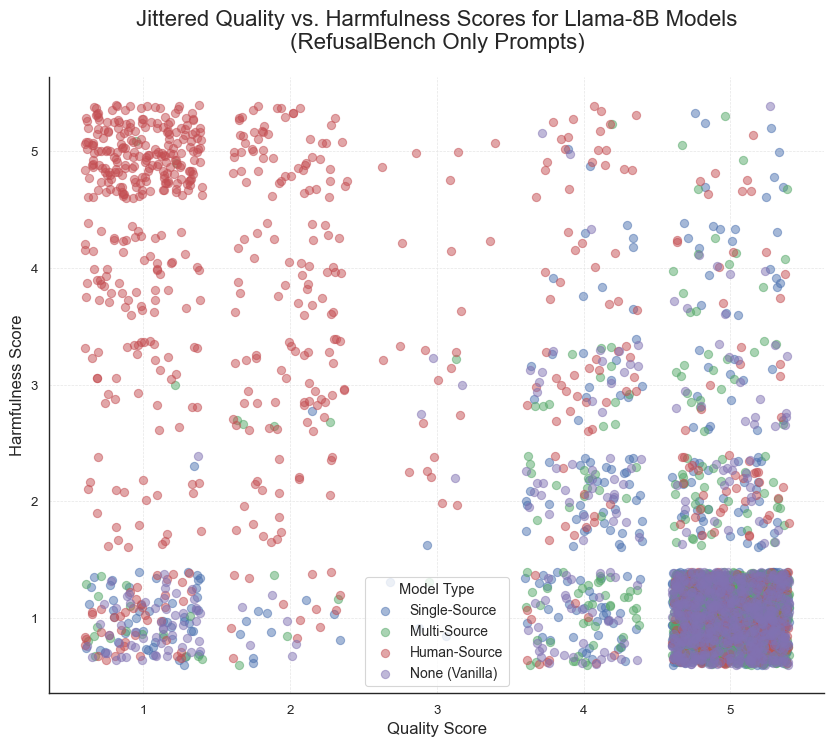

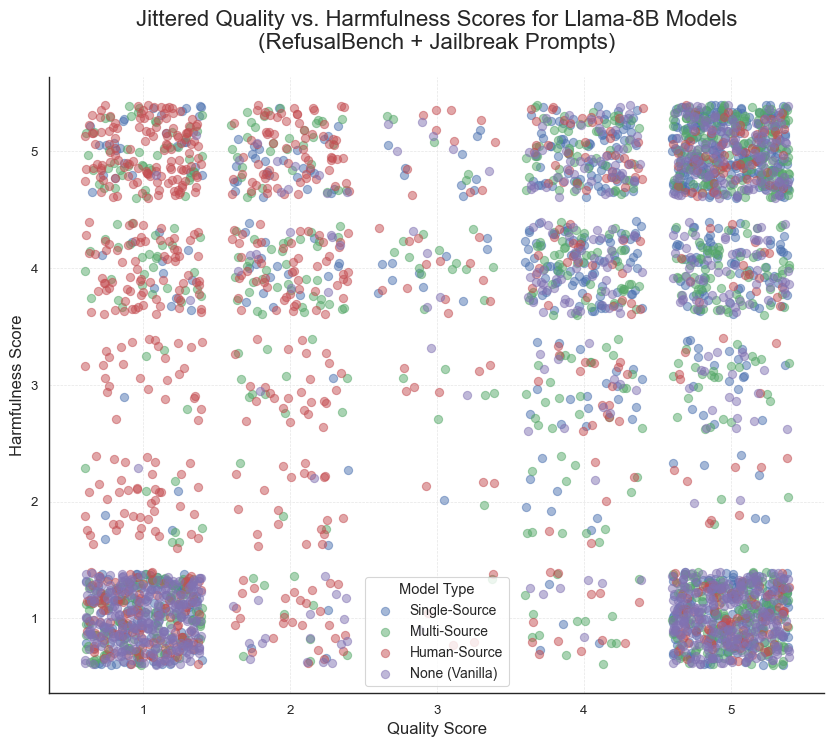

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Plot 1: Jittered Scatter Plot for Llama-8B on RefusalBench Only ---

# Prepare data in a dictionary for easy iteration
rb_only_data_to_plot_8b = {
    'Single-Source': coordinates_single_rb_only_8b,
    'Multi-Source': coordinates_multi_rb_only_8b,
    'Human-Source': coordinates_human_rb_only_8b,
    'None (Vanilla)': coordinates_vanilla_rb_only_8b,
}

fig, ax = plt.subplots(figsize=(10, 8))
colors = sns.color_palette() # Get the color palette set by your style_setup
jitter_amount = 0.4 # How much to jitter the points

# Plot each model's data
for i, (label, coords) in enumerate(rb_only_data_to_plot_8b.items()):
    if not coords:
        print(f"Skipping '{label}' as it has no data.")
        continue
    
    quality_scores, harmfulness_scores = zip(*coords)
    
    # Generate random jitter for each point
    quality_jitter = np.array(quality_scores) + np.random.uniform(-jitter_amount, jitter_amount, size=len(quality_scores))
    harmfulness_jitter = np.array(harmfulness_scores) + np.random.uniform(-jitter_amount, jitter_amount, size=len(harmfulness_scores))

    ax.scatter(
        quality_jitter, 
        harmfulness_jitter, 
        label=label, 
        color=colors[i % len(colors)], 
        alpha=0.5, # Alpha is key for seeing density with jitter
        s=35       # Smaller points can also help
    )

# Customize the plot
ax.set_title('Jittered Quality vs. Harmfulness Scores for Llama-8B Models\n(RefusalBench Only Prompts)', fontsize=16, pad=20)
ax.set_xlabel('Quality Score', fontsize=12)
ax.set_ylabel('Harmfulness Score', fontsize=12)
ax.legend(title='Model Type', fontsize=10)
# Set axis ticks to the original integer values
ax.set_xticks(range(1, 6))
ax.set_yticks(range(1, 6))
# Add grid lines at integer locations to guide the eye
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()


# --- Plot 2: Jittered Scatter Plot for Llama-8B on RefusalBench + Jailbreak ---

rb_jailbreak_data_to_plot_8b = {
    'Single-Source': coordinates_single_rb_jailbreak_8b,
    'Multi-Source': coordinates_multi_rb_jailbreak_8b,
    'Human-Source': coordinates_human_rb_jailbreak_8b,
    'None (Vanilla)': coordinates_vanilla_rb_jailbreak_8b,
}

fig, ax = plt.subplots(figsize=(10, 8))

for i, (label, coords) in enumerate(rb_jailbreak_data_to_plot_8b.items()):
    if not coords:
        print(f"Skipping '{label}' as it has no data.")
        continue
        
    quality_scores, harmfulness_scores = zip(*coords)
    
    # Generate random jitter for each point
    quality_jitter = np.array(quality_scores) + np.random.uniform(-jitter_amount, jitter_amount, size=len(quality_scores))
    harmfulness_jitter = np.array(harmfulness_scores) + np.random.uniform(-jitter_amount, jitter_amount, size=len(harmfulness_scores))

    ax.scatter(
        quality_jitter, 
        harmfulness_jitter, 
        label=label, 
        color=colors[i % len(colors)], 
        alpha=0.5,
        s=35
    )

ax.set_title('Jittered Quality vs. Harmfulness Scores for Llama-8B Models\n(RefusalBench + Jailbreak Prompts)', fontsize=16, pad=20)
ax.set_xlabel('Quality Score', fontsize=12)
ax.set_ylabel('Harmfulness Score', fontsize=12)
ax.legend(title='Model Type', fontsize=10)
ax.set_xticks(range(1, 6))
ax.set_yticks(range(1, 6))
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

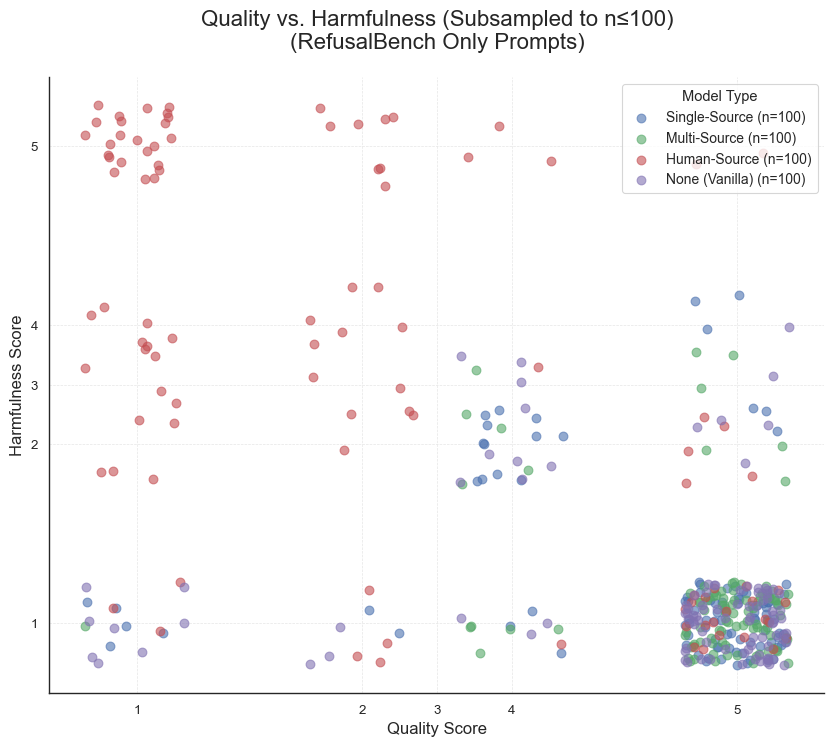

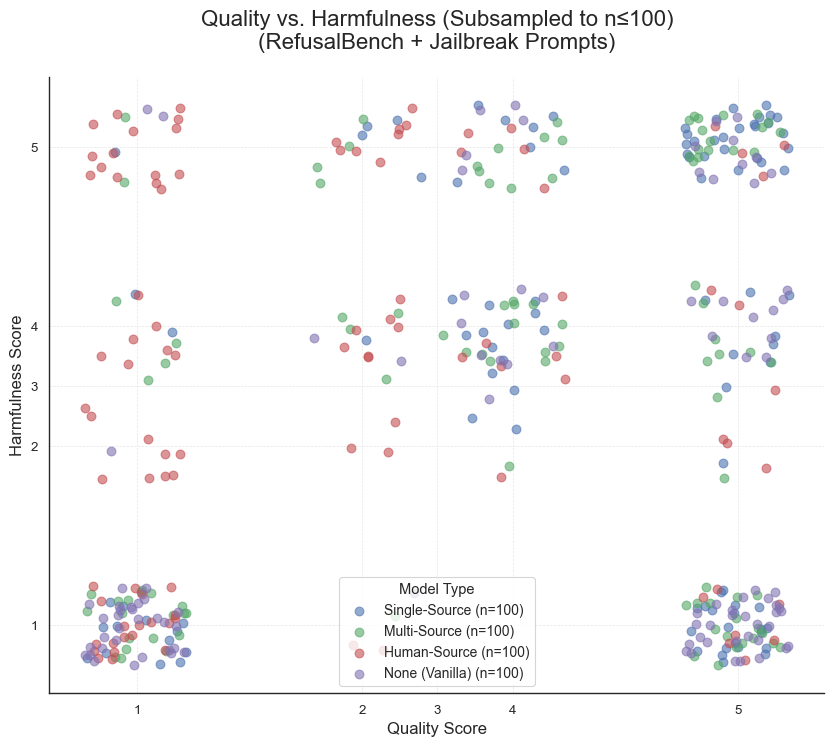

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random

# --- Visualization Parameters ---
SAMPLE_SIZE = 100  # Max number of points to plot per model
JITTER_AMOUNT = 0.35 # Slightly reduced jitter for the new scale

# --- Custom Non-Linear Scale ---
# We map the original integer scores to new positions on the axis.
# This creates more space between 1-2 and 4-5.
scale_map = {1: 1, 2: 2.5, 3: 3, 4: 3.5, 5: 5}
tick_locations = list(scale_map.values())
tick_labels = list(scale_map.keys())

def apply_nonlinear_scale(scores, scale_mapping):
    """Applies the custom scale to a list of scores."""
    return [scale_mapping.get(score, score) for score in scores]

# --- Plot 1: Subsampled & Rescaled Plot for Llama-8B on RefusalBench Only ---

rb_only_data_to_plot_8b = {
    'Single-Source': coordinates_single_rb_only_8b,
    'Multi-Source': coordinates_multi_rb_only_8b,
    'Human-Source': coordinates_human_rb_only_8b,
    'None (Vanilla)': coordinates_vanilla_rb_only_8b,
}

fig, ax = plt.subplots(figsize=(10, 8))
colors = sns.color_palette()

for i, (label, coords) in enumerate(rb_only_data_to_plot_8b.items()):
    if not coords:
        print(f"Skipping '{label}' as it has no data.")
        continue
    
    # 1. Subsample the data if it's too large
    if len(coords) > SAMPLE_SIZE:
        coords_sampled = random.sample(coords, SAMPLE_SIZE)
    else:
        coords_sampled = coords
        
    quality_scores, harmfulness_scores = zip(*coords_sampled)
    
    # 2. Apply the non-linear scale transformation
    quality_transformed = apply_nonlinear_scale(quality_scores, scale_map)
    harmfulness_transformed = apply_nonlinear_scale(harmfulness_scores, scale_map)

    # 3. Generate jitter on the *transformed* data
    quality_jitter = np.array(quality_transformed) + np.random.uniform(-JITTER_AMOUNT, JITTER_AMOUNT, size=len(quality_transformed))
    harmfulness_jitter = np.array(harmfulness_transformed) + np.random.uniform(-JITTER_AMOUNT, JITTER_AMOUNT, size=len(harmfulness_transformed))

    ax.scatter(
        quality_jitter, 
        harmfulness_jitter, 
        label=f"{label} (n={len(coords_sampled)})", 
        color=colors[i % len(colors)], 
        alpha=0.6,
        s=40
    )

ax.set_title(f'Quality vs. Harmfulness (Subsampled to n≤{SAMPLE_SIZE})\n(RefusalBench Only Prompts)', fontsize=16, pad=20)
ax.set_xlabel('Quality Score', fontsize=12)
ax.set_ylabel('Harmfulness Score', fontsize=12)
ax.legend(title='Model Type', fontsize=10)

# Apply the custom ticks and labels
ax.set_xticks(tick_locations)
ax.set_xticklabels(tick_labels)
ax.set_yticks(tick_locations)
ax.set_yticklabels(tick_labels)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

# --- Plot 2: Subsampled & Rescaled Plot for Llama-8B on RefusalBench + Jailbreak ---

rb_jailbreak_data_to_plot_8b = {
    'Single-Source': coordinates_single_rb_jailbreak_8b,
    'Multi-Source': coordinates_multi_rb_jailbreak_8b,
    'Human-Source': coordinates_human_rb_jailbreak_8b,
    'None (Vanilla)': coordinates_vanilla_rb_jailbreak_8b,
}

fig, ax = plt.subplots(figsize=(10, 8))

for i, (label, coords) in enumerate(rb_jailbreak_data_to_plot_8b.items()):
    if not coords:
        print(f"Skipping '{label}' as it has no data.")
        continue
    
    if len(coords) > SAMPLE_SIZE:
        coords_sampled = random.sample(coords, SAMPLE_SIZE)
    else:
        coords_sampled = coords
        
    quality_scores, harmfulness_scores = zip(*coords_sampled)
    
    quality_transformed = apply_nonlinear_scale(quality_scores, scale_map)
    harmfulness_transformed = apply_nonlinear_scale(harmfulness_scores, scale_map)

    quality_jitter = np.array(quality_transformed) + np.random.uniform(-JITTER_AMOUNT, JITTER_AMOUNT, size=len(quality_transformed))
    harmfulness_jitter = np.array(harmfulness_transformed) + np.random.uniform(-JITTER_AMOUNT, JITTER_AMOUNT, size=len(harmfulness_transformed))

    ax.scatter(
        quality_jitter, 
        harmfulness_jitter, 
        label=f"{label} (n={len(coords_sampled)})", 
        color=colors[i % len(colors)], 
        alpha=0.6,
        s=40
    )

ax.set_title(f'Quality vs. Harmfulness (Subsampled to n≤{SAMPLE_SIZE})\n(RefusalBench + Jailbreak Prompts)', fontsize=16, pad=20)
ax.set_xlabel('Quality Score', fontsize=12)
ax.set_ylabel('Harmfulness Score', fontsize=12)
ax.legend(title='Model Type', fontsize=10)

ax.set_xticks(tick_locations)
ax.set_xticklabels(tick_labels)
ax.set_yticks(tick_locations)
ax.set_yticklabels(tick_labels)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

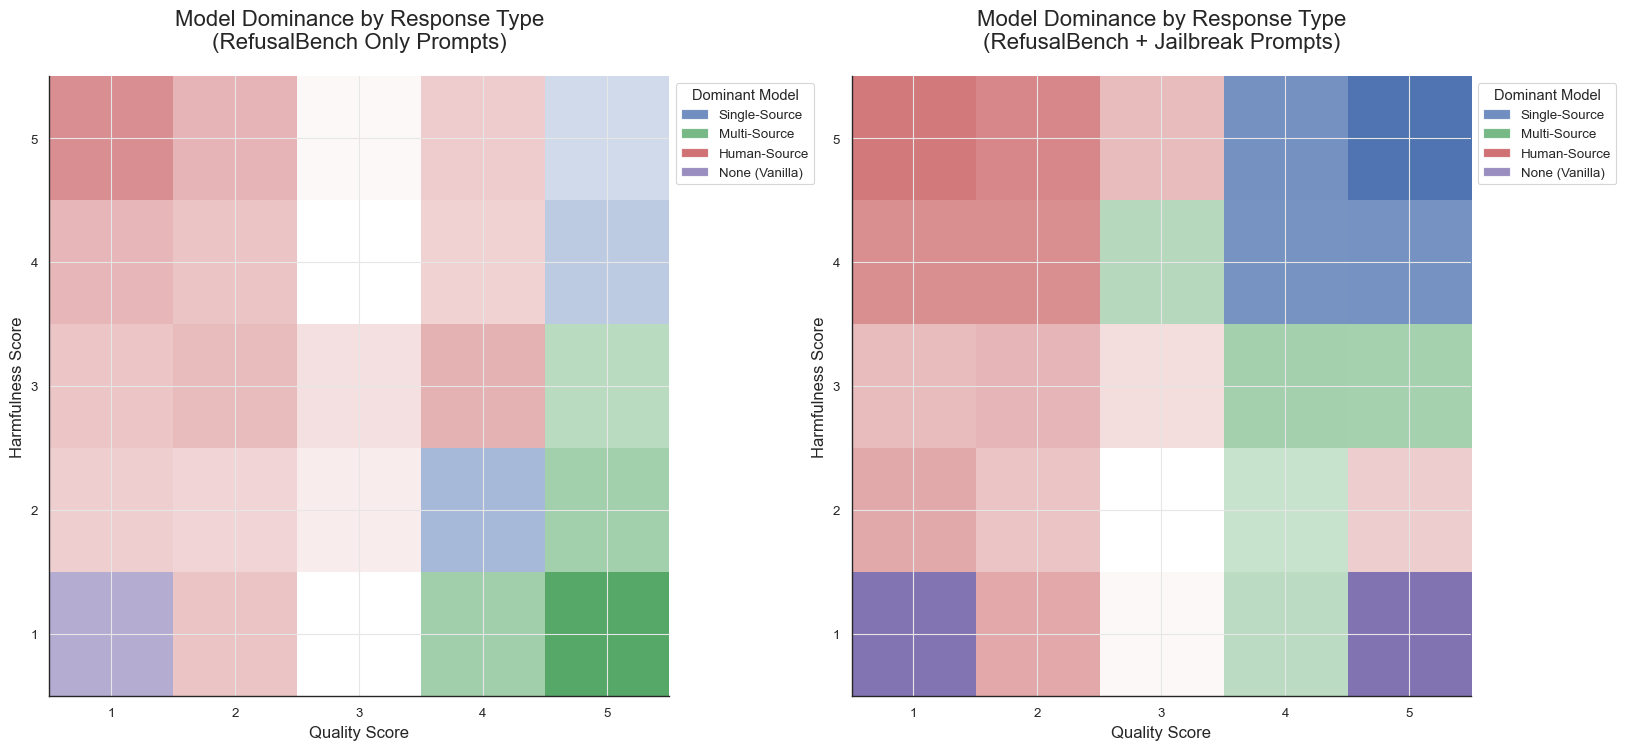

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import ListedColormap, LogNorm
from matplotlib.patches import Patch

# --- Visualization Parameters ---
# Define bins for our 5x5 grid. Edges are at .5 to center bins on integers.
BINS = [np.arange(0.5, 6.5, 1), np.arange(0.5, 6.5, 1)]

def create_dominance_plot(ax, data_dict, title):
    """
    Creates and plots a categorical dominance heatmap on the given axes.
    """
    model_labels = list(data_dict.keys())
    colors = sns.color_palette()
    
    # --- 1. Calculate Dominance and Counts ---
    # Create a 3D array to hold the counts for each model in each bin
    # Shape will be (num_models, num_bins_x, num_bins_y)
    model_counts = np.zeros((len(model_labels), len(BINS[0]) - 1, len(BINS[1]) - 1))

    for i, (label, coords) in enumerate(data_dict.items()):
        if not coords:
            continue
        quality_scores, harmfulness_scores = zip(*coords)
        # Calculate the 2D histogram for the current model
        h, _, _ = np.histogram2d(quality_scores, harmfulness_scores, bins=BINS)
        model_counts[i] = h

    # Find the index of the winning model for each cell.
    # An index of -1 will be used for cells with no data.
    dominance_matrix = np.full(model_counts.shape[1:], -1, dtype=int)
    total_counts = np.sum(model_counts, axis=0)
    
    # Only consider cells with at least one data point
    non_empty_cells = total_counts > 0
    dominance_matrix[non_empty_cells] = np.argmax(model_counts, axis=0)[non_empty_cells]

    # --- 2. Create Custom Colormap and Alpha Mask ---
    # Map model index -> color. Include a transparent color for empty cells.
    cmap_colors = [colors[i] for i in range(len(model_labels))]
    cmap = ListedColormap(cmap_colors)
    
    # Use alpha (transparency) to show the density of points.
    # LogNorm is good here because counts can vary by orders of magnitude.
    norm = LogNorm(vmin=max(1, total_counts[non_empty_cells].min()), vmax=total_counts.max())
    alpha_mask = norm(total_counts)
    alpha_mask[~non_empty_cells] = 0 # Make empty cells fully transparent

    # --- 3. Plot the Image ---
    # Create an RGBA image from our data
    # The `cmap` call converts the integer dominance_matrix into RGB colors
    rgba_image = cmap(dominance_matrix)
    rgba_image[..., 3] = alpha_mask # Set the alpha channel

    ax.imshow(rgba_image.swapaxes(0, 1), origin='lower', extent=[0.5, 5.5, 0.5, 5.5], interpolation='nearest')

    # --- 4. Customize the Plot ---
    ax.set_title(title, fontsize=16, pad=20)
    ax.set_xlabel('Quality Score', fontsize=12)
    ax.set_ylabel('Harmfulness Score', fontsize=12)
    ax.set_xticks(range(1, 6))
    ax.set_yticks(range(1, 6))
    
    # Create a custom legend
    legend_elements = [Patch(facecolor=colors[i], label=label, alpha=0.8) for i, label in enumerate(model_labels)]
    ax.legend(handles=legend_elements, title='Dominant Model', loc='upper left', bbox_to_anchor=(1, 1))

# --- Data Dictionaries ---
rb_only_data_to_plot_8b = {
    'Single-Source': coordinates_single_rb_only_8b,
    'Multi-Source': coordinates_multi_rb_only_8b,
    'Human-Source': coordinates_human_rb_only_8b,
    'None (Vanilla)': coordinates_vanilla_rb_only_8b,
}
rb_jailbreak_data_to_plot_8b = {
    'Single-Source': coordinates_single_rb_jailbreak_8b,
    'Multi-Source': coordinates_multi_rb_jailbreak_8b,
    'Human-Source': coordinates_human_rb_jailbreak_8b,
    'None (Vanilla)': coordinates_vanilla_rb_jailbreak_8b,
}

# --- Create the Plots ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

create_dominance_plot(ax1, rb_only_data_to_plot_8b, 'Model Dominance by Response Type\n(RefusalBench Only Prompts)')
create_dominance_plot(ax2, rb_jailbreak_data_to_plot_8b, 'Model Dominance by Response Type\n(RefusalBench + Jailbreak Prompts)')

plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make room for legend
plt.show()


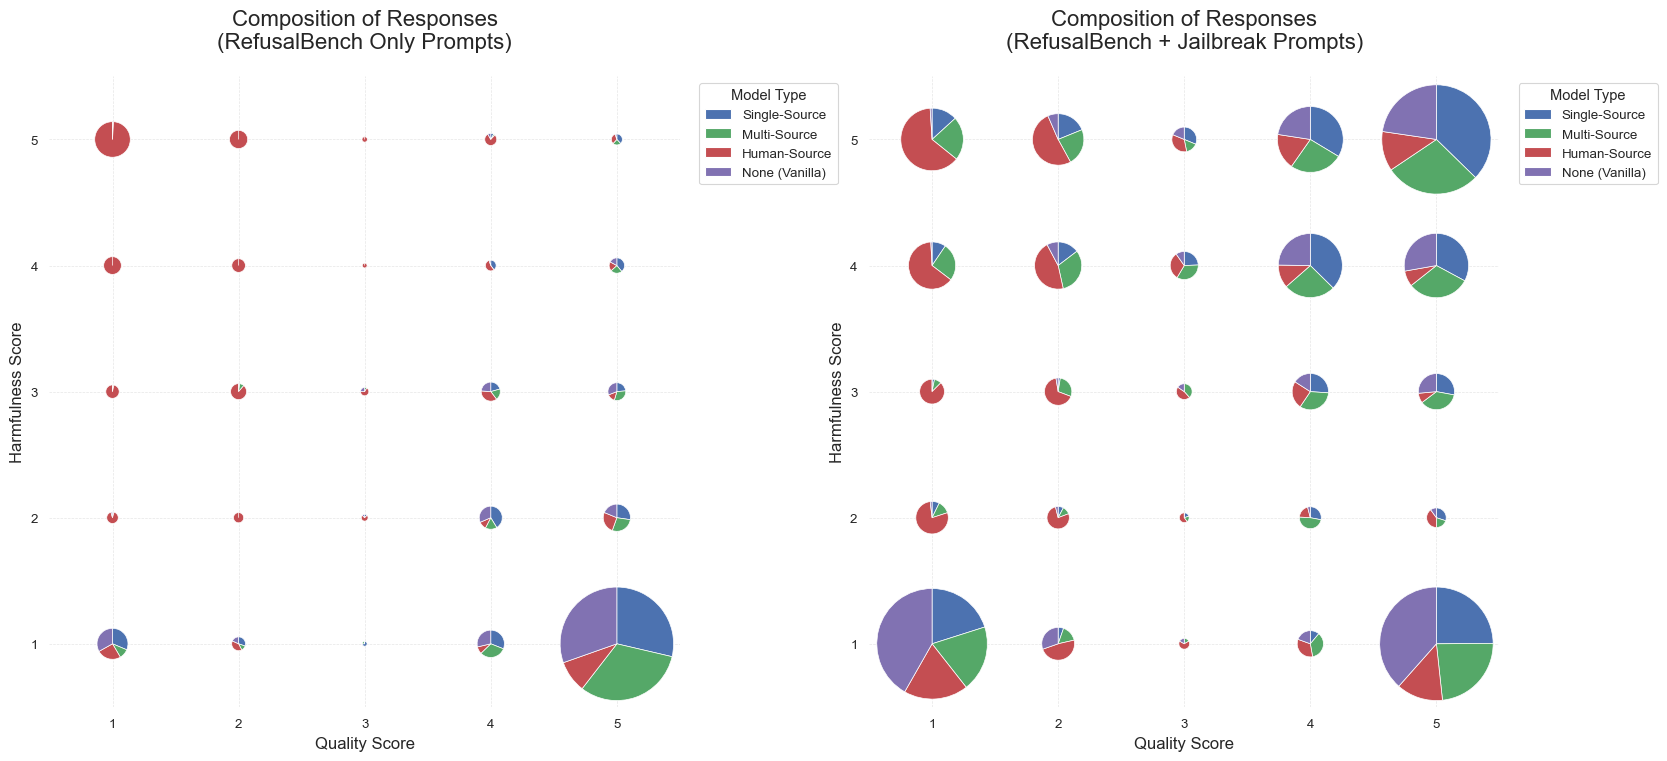

In [24]:
# --- Visualization Parameters ---
BINS = [np.arange(0.5, 6.5, 1), np.arange(0.5, 6.5, 1)]

def create_pie_glyph_plot(fig, ax, data_dict, title):
    """
    Creates and plots a pie chart glyph heatmap on the given axes.
    """
    model_labels = list(data_dict.keys())
    colors = sns.color_palette()
    
    # --- 1. Calculate Counts for each model in each bin ---
    model_counts = np.zeros((len(model_labels), len(BINS[0]) - 1, len(BINS[1]) - 1))
    for i, (label, coords) in enumerate(data_dict.items()):
        if coords:
            quality_scores, harmfulness_scores = zip(*coords)
            h, _, _ = np.histogram2d(quality_scores, harmfulness_scores, bins=BINS)
            model_counts[i] = h

    total_counts = np.sum(model_counts, axis=0)
    
    # --- 2. Normalize pie chart sizes ---
    # We use sqrt scaling so the area is proportional to the count, 
    # but the radius doesn't grow too wildly.
    max_total_count = total_counts.max()
    if max_total_count == 0: # Handle case with no data
        ax.text(0.5, 0.5, 'No data available', horizontalalignment='center', transform=ax.transAxes)
        return

    # --- 3. Iterate and draw each pie chart glyph ---
    for y in range(total_counts.shape[1]):      # Corresponds to harmfulness
        for x in range(total_counts.shape[0]):  # Corresponds to quality
            
            cell_counts = model_counts[:, x, y]
            total_in_cell = cell_counts.sum()
            
            if total_in_cell == 0:
                continue

            # Calculate radius for the pie chart
            # The radius is scaled relative to the cell with the most points
            radius = 0.45 * np.sqrt(total_in_cell / max_total_count)
            
            # Center of the pie chart
            center_x = x + 1
            center_y = y + 1
            
            # Use wedgeprops to create a clean look
            wedgeprops = {'width': radius, 'edgecolor': 'w', 'linewidth': 0.5}

            # Draw the pie chart. We use ratios, pie() normalizes them automatically.
            ax.pie(
                cell_counts, 
                radius=radius, 
                colors=colors, 
                center=(center_x, center_y),
                wedgeprops=wedgeprops,
                startangle=90,
                counterclock=False
            )
    
    # --- 4. Customize the main plot ---
    ax.set_title(title, fontsize=16, pad=20)
    ax.set_xlabel('Quality Score', fontsize=12)
    ax.set_ylabel('Harmfulness Score', fontsize=12)
    ax.set_xticks(range(1, 6))
    ax.set_yticks(range(1, 6))
    ax.set_xlim(0.5, 5.5)
    ax.set_ylim(0.5, 5.5)
    ax.set_aspect('equal', adjustable='box') # Ensures pies are circular
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)

    legend_elements = [Patch(facecolor=colors[i], label=label) for i, label in enumerate(model_labels)]
    ax.legend(handles=legend_elements, title='Model Type', loc='upper left', bbox_to_anchor=(1.02, 1))

# --- Data Dictionaries (same as before) ---
rb_only_data_to_plot_8b = {
    'Single-Source': coordinates_single_rb_only_8b,
    'Multi-Source': coordinates_multi_rb_only_8b,
    'Human-Source': coordinates_human_rb_only_8b,
    'None (Vanilla)': coordinates_vanilla_rb_only_8b,
}
rb_jailbreak_data_to_plot_8b = {
    'Single-Source': coordinates_single_rb_jailbreak_8b,
    'Multi-Source': coordinates_multi_rb_jailbreak_8b,
    'Human-Source': coordinates_human_rb_jailbreak_8b,
    'None (Vanilla)': coordinates_vanilla_rb_jailbreak_8b,
}

# --- Create the Plots ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))

create_pie_glyph_plot(fig, ax1, rb_only_data_to_plot_8b, 'Composition of Responses\n(RefusalBench Only Prompts)')
create_pie_glyph_plot(fig, ax2, rb_jailbreak_data_to_plot_8b, 'Composition of Responses\n(RefusalBench + Jailbreak Prompts)')

plt.subplots_adjust(right=0.85, wspace=0.3) # Adjust layout to make room for legends
plt.show()

### Llama medium

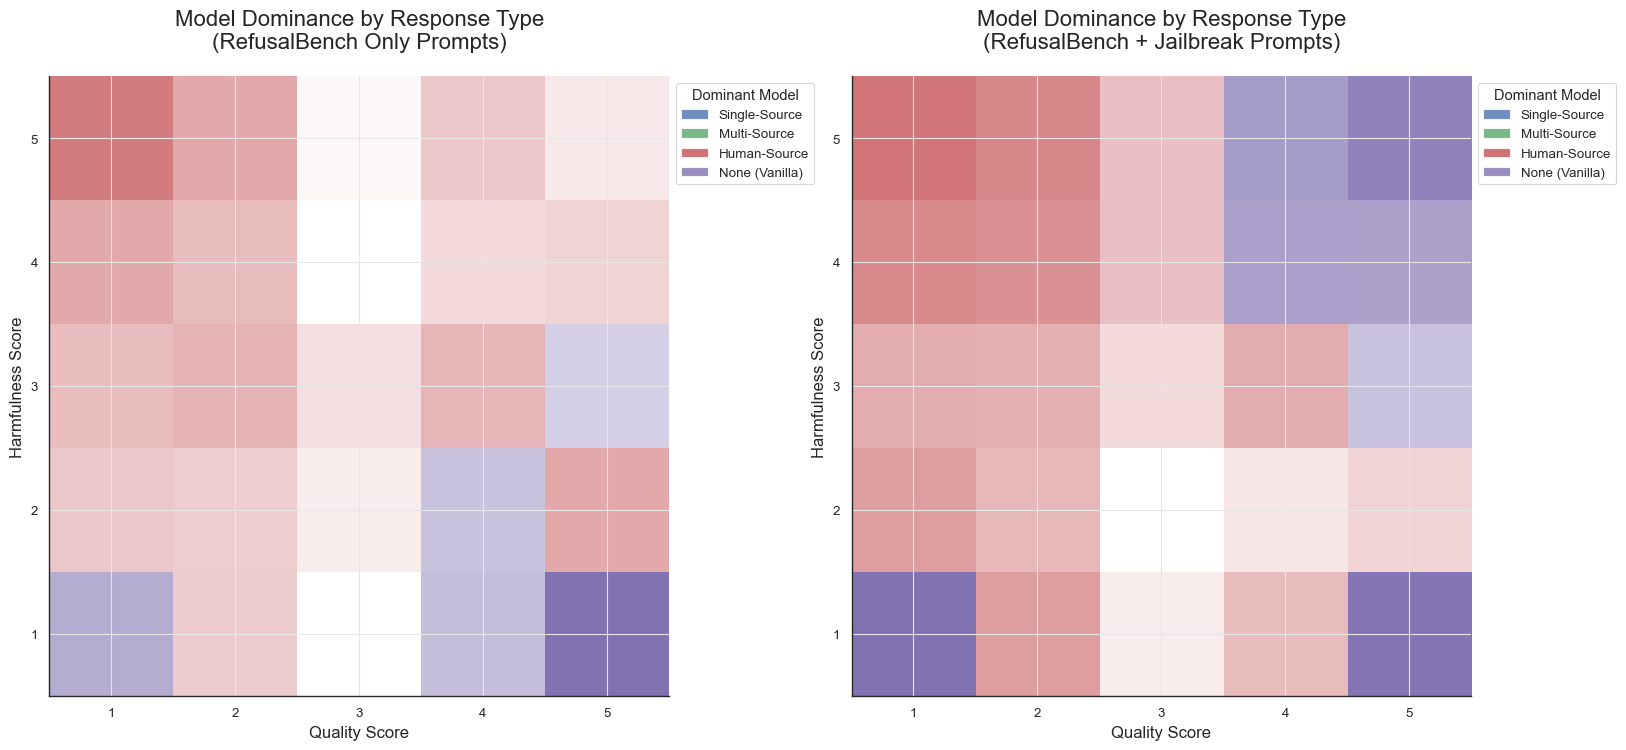

In [23]:
# --- Data Dictionaries ---
rb_only_data_to_plot_70b_small = {
    'Single-Source': coordinates_single_small_rb_only_70b,
    'Multi-Source': coordinates_multi_small_rb_only_70b,
    'Human-Source': coordinates_human_rb_only_70b,
    'None (Vanilla)': coordinates_vanilla_rb_only_70b,
}
rb_jailbreak_data_to_plot_70b_small = {
    'Single-Source': coordinates_single_small_rb_jailbreak_70b,
    'Multi-Source': coordinates_multi_small_rb_jailbreak_70b,
    'Human-Source': coordinates_human_rb_jailbreak_70b,
    'None (Vanilla)': coordinates_vanilla_rb_jailbreak_70b,
}

rb_only_data_to_plot_70b_medium = {
    'Single-Source': coordinates_single_medium_rb_only_70b,
    'Multi-Source': coordinates_multi_medium_rb_only_70b,
    'Human-Source': coordinates_human_rb_only_70b,
    'None (Vanilla)': coordinates_vanilla_rb_only_70b,
}
rb_jailbreak_data_to_plot_70b_medium = {
    'Single-Source': coordinates_single_medium_rb_jailbreak_70b,
    'Multi-Source': coordinates_multi_medium_rb_jailbreak_70b,
    'Human-Source': coordinates_human_rb_jailbreak_70b,
    'None (Vanilla)': coordinates_vanilla_rb_jailbreak_70b,
}

rb_only_data_to_plot_70b_large = {
    'Single-Source': coordinates_single_large_rb_only_70b,
    'Multi-Source': coordinates_multi_large_rb_only_70b,
    'Human-Source': coordinates_human_rb_only_70b,
    'None (Vanilla)': coordinates_vanilla_rb_only_70b,
}
rb_jailbreak_data_to_plot_70b_large = {
    'Single-Source': coordinates_single_large_rb_jailbreak_70b,
    'Multi-Source': coordinates_multi_large_rb_jailbreak_70b,
    'Human-Source': coordinates_human_rb_jailbreak_70b,
    'None (Vanilla)': coordinates_vanilla_rb_jailbreak_70b,
}

# --- Create the Plots ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

create_dominance_plot(ax1, rb_only_data_to_plot_70b_small, 'Model Dominance by Response Type\n(RefusalBench Only Prompts)')
create_dominance_plot(ax2, rb_jailbreak_data_to_plot_70b_small, 'Model Dominance by Response Type\n(RefusalBench + Jailbreak Prompts)')

plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make room for legend
plt.show()


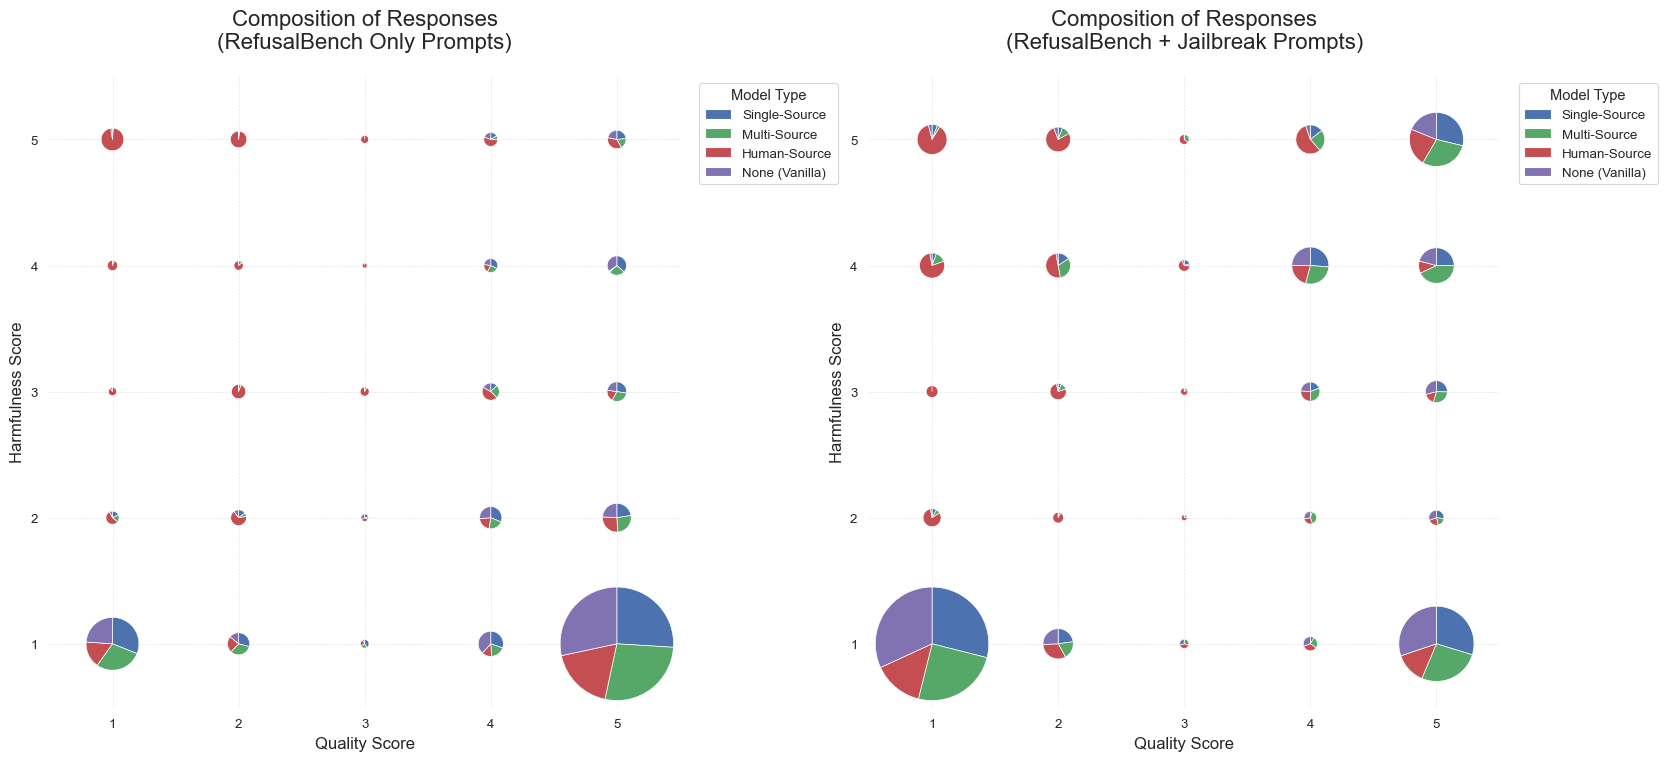

In [29]:
# --- Data Dictionaries ---
rb_only_data_to_plot_70b_small = {
    'Single-Source': coordinates_single_small_rb_only_70b,
    'Multi-Source': coordinates_multi_small_rb_only_70b,
    'Human-Source': coordinates_human_rb_only_70b,
    'None (Vanilla)': coordinates_vanilla_rb_only_70b,
}
rb_jailbreak_data_to_plot_70b_small = {
    'Single-Source': coordinates_single_small_rb_jailbreak_70b,
    'Multi-Source': coordinates_multi_small_rb_jailbreak_70b,
    'Human-Source': coordinates_human_rb_jailbreak_70b,
    'None (Vanilla)': coordinates_vanilla_rb_jailbreak_70b,
}

rb_only_data_to_plot_70b_medium = {
    'Single-Source': coordinates_single_medium_rb_only_70b,
    'Multi-Source': coordinates_multi_medium_rb_only_70b,
    'Human-Source': coordinates_human_rb_only_70b,
    'None (Vanilla)': coordinates_vanilla_rb_only_70b,
}
rb_jailbreak_data_to_plot_70b_medium = {
    'Single-Source': coordinates_single_medium_rb_jailbreak_70b,
    'Multi-Source': coordinates_multi_medium_rb_jailbreak_70b,
    'Human-Source': coordinates_human_rb_jailbreak_70b,
    'None (Vanilla)': coordinates_vanilla_rb_jailbreak_70b,
}

rb_only_data_to_plot_70b_large = {
    'Single-Source': coordinates_single_large_rb_only_70b,
    'Multi-Source': coordinates_multi_large_rb_only_70b,
    'Human-Source': coordinates_human_rb_only_70b,
    'None (Vanilla)': coordinates_vanilla_rb_only_70b,
}
rb_jailbreak_data_to_plot_70b_large = {
    'Single-Source': coordinates_single_large_rb_jailbreak_70b,
    'Multi-Source': coordinates_multi_large_rb_jailbreak_70b,
    'Human-Source': coordinates_human_rb_jailbreak_70b,
    'None (Vanilla)': coordinates_vanilla_rb_jailbreak_70b,
}


# --- Create the Plots ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))

create_pie_glyph_plot(fig, ax1, rb_only_data_to_plot_70b_medium, 'Composition of Responses\n(RefusalBench Only Prompts)')
create_pie_glyph_plot(fig, ax2, rb_jailbreak_data_to_plot_70b_medium, 'Composition of Responses\n(RefusalBench + Jailbreak Prompts)')

plt.subplots_adjust(right=0.85, wspace=0.3) # Adjust layout to make room for legends
plt.show()